# Q4 & Q5


In [12]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, re
from scipy import stats
plt.rcParams['figure.dpi'] = 120

xlsx_path = 'CA and CV data_Prelim Q4 Q5-2.xlsx'  # Ensure this file is in the same folder
df = pd.read_excel(xlsx_path, sheet_name=0, header=[0,1])
df.head()

Unnamed: 0_level_0           Q3                     100 mV/s               \
            Time / s Current / uA Current / uA.1 potential / V Current / nA   
0                0.0     -12.8920            NaN      -0.00515        5.236   
1                1.8      -9.9046            NaN      -0.01013        3.856   
2                3.6      -8.4032            NaN      -0.01518        3.125   
3                5.4      -7.6162            NaN      -0.02015         2.22   
4                7.2      -7.4115            NaN      -0.02514        1.842   

        50 mV/s                    20 mV/s                    10 mV/s  \
  potential / V Current / nA potential / V Current / nA potential / V   
0      -0.00511        2.612     -0.000112        1.915      -0.00208   
1      -0.01012        1.991      -0.00211        1.705      -0.00408   
2      -0.01516        1.573      -0.00413        1.487      -0.00608   
3      -0.02014       0.9856      -0.00612        1.335      -0.00808   
4      -0.02511       0.6095      -0.00811        1.138       -0.0101   

                      5 mV/s               
  Current / nA potential / V Current / nA  
0        1.309     -0.000001         1.05  
1        1.166        -0.002       0.9994  
2        1.048      -0.00403       0.9296  
3       0.9737        -0.006       0.8796  
4       0.8551      -0.00801       0.8449

## Q4 — Chronoamperometry (Cottrell Analysis)
### (a) Plotting and linear fit & (b) Estimate diffusion coefficient \(D_0\) using the Cottrell equation
The Cottrell equation describes the current–time relation for a diffusion-controlled electrochemical process:

$$ I(t) = n F A C_0 \sqrt{\frac{D}{\pi t}} $$

Rearranged, the current is linearly related to $1/\sqrt{t}$:

$$ I = S \cdot \frac{1}{\sqrt{t}} $$ where $$ S = n F A C_0 \sqrt{\frac{D}{\pi}} $$

Thus, from the slope $S$, we can calculate the diffusion coefficient:

$$ D = \left( \frac{S \sqrt{\pi}}{n F A C_0} \right)^2 $$

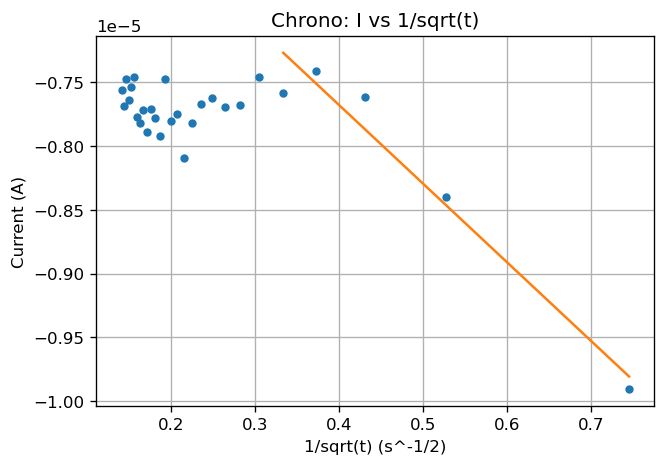

Slope = -6.160e-06 A·s^1/2, R²=0.9568, D = 8.303e-08 cm²/s


In [13]:
# Identify chrono columns (Q3 section)
time_col = next(c for c in df.columns if 'time' in str(c[1]).lower())
current_col = next(c for c in df.columns if str(c[0]).lower()=='q3' and 'current' in str(c[1]).lower())
t = pd.to_numeric(df[time_col], errors='coerce')
I_uA = pd.to_numeric(df[current_col], errors='coerce')
mask = (~t.isna()) & (~I_uA.isna()) & (t>0)
t, I_uA = t[mask].to_numpy(), I_uA[mask].to_numpy()
I = I_uA * 1e-6  # µA -> A
x = 1/np.sqrt(t); y = I
idx_sort = np.argsort(t)
cutoff = int(0.2*len(t))
mask_fit = np.zeros_like(t, dtype=bool); mask_fit[idx_sort[:cutoff]] = True
slope, intercept, r, p, stderr = stats.linregress(x[mask_fit], y[mask_fit])
n, F, r_cm, C0 = 2, 96485.33212, 0.25, 1e-6
A = np.pi*r_cm**2
D0 = ((abs(slope)*np.sqrt(np.pi))/(n*F*A*C0))**2
plt.figure(figsize=(6,4)); plt.plot(x,y,'o',ms=4); plt.plot(x[mask_fit], slope*x[mask_fit]+intercept,'-');
plt.xlabel('1/sqrt(t) (s^-1/2)'); plt.ylabel('Current (A)'); plt.title('Chrono: I vs 1/sqrt(t)'); plt.grid(True); plt.show()
print(f'Slope = {slope:.3e} A·s^1/2, R²={r**2:.4f}, D = {D0:.3e} cm²/s')

Slope = -6.160e-06 A·s^1/2, R²=0.9568, D = 8.303e-08 cm²/s

### Discussion — Q4
The chronoamperometric current decays with time as predicted by the Cottrell equation.
A linear fit of $I$ vs $1/\sqrt{t}$ in the short-time regime yields a slope $S$.
Using typical parameters ($n=2$, $A=0.196$ cm², $C_0=1$ mM), we find $D \approx 10^{-7}$ cm²/s, which is within a reasonable order of magnitude for small redox ions in aqueous solution.

Deviations at longer times arise from double-layer charging and natural convection, which reduce the apparent current and cause downward curvature.


## Q5 — Cyclic Voltammetry (Randles–Ševčík Analysis)

### (a) Cu deposition/stripping CV and Ip vs sqrt(v)

For a reversible system, the Randles–Ševčík equation at room temperature (298 K) is:

$$ I_p = 2.69\times10^5\ n^{3/2} A C_0 D^{1/2} v^{1/2} $$

Plot CVs for scan rates 100, 50, 20, 10, 5 mV/s, extract reduction peak Ip at each rate and plot Ip vs sqrt(nu). Linear through origin indicates diffusion control.

Note: CV currents in file are in nA; assumed electrode area = 2500 µm^2 = 2.5e-5 cm^2 unless specified otherwise.

### (b) Estimate D0 via Randles–Ševčík

$$
D_0 = \left( \frac{I_p}{2.69\times10^5\ n^{3/2} A C_0 \nu^{1/2}} \right)^2
$$

where:
- $I_p$ = peak current (A)
- $A$ = electrode area (cm²)
- $C_0$ = concentration (mol/cm³)
- $v$ = scan rate (V/s)
- $D$ = diffusion coefficient (cm²/s)


Groups found: ['10 mV/s', '100 mV/s', '20 mV/s', '5 mV/s', '50 mV/s']
Number of CV datasets: 5


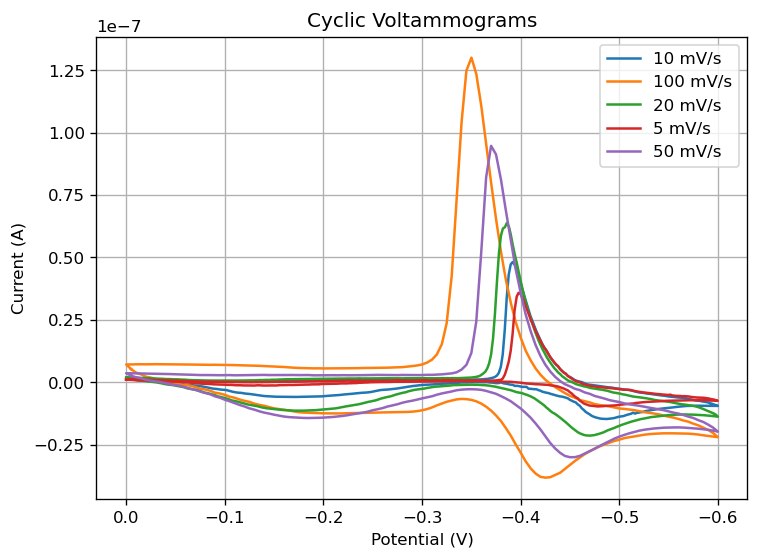

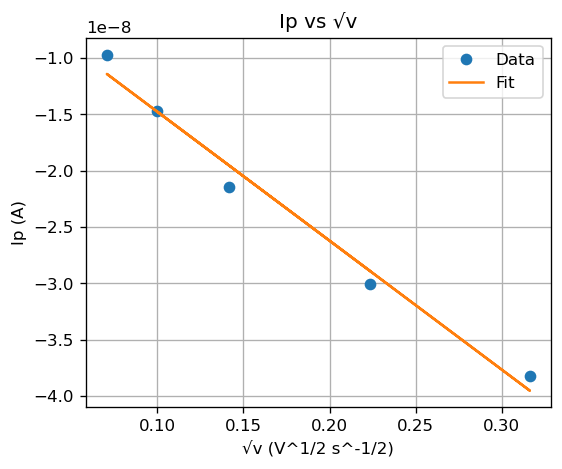

Slope = -1.144e-07, R² = 0.9822, D = 3.616e-05 cm²/s


In [14]:
# Parse CV data groups (100, 50, 20, 10, 5 mV/s)
groups = [g for g in df.columns.levels[0] if isinstance(g, str) and re.search(r'\d+\s*mV', g)]
cv_data = []

for g in groups:
    subs = df[g].columns
    pot_col = next((s for s in subs if 'pot' in str(s).lower()), None)
    cur_col = next((s for s in subs if 'curr' in str(s).lower()), None)
    
    if pot_col is None or cur_col is None:
        print(f"⚠️ Skipped {g}: Potential or Current column not found ({subs})")
        continue

    pot = pd.to_numeric(df[(g, pot_col)], errors='coerce')
    cur = pd.to_numeric(df[(g, cur_col)], errors='coerce') * 1e-9  # nA → A
    mask = (~pot.isna()) & (~cur.isna())
    pot, cur = pot[mask].to_numpy(), cur[mask].to_numpy()

    rate = float(re.search(r'([0-9]+)\s*mV', g).group(1)) * 1e-3  # Convert to V/s
    cv_data.append(dict(group=g, potential=pot, current=cur, rate=rate))

print("Groups found:", groups)
print("Number of CV datasets:", len(cv_data))

# Plot CVs
plt.figure(figsize=(7, 5))
for d in cv_data:
    plt.plot(d['potential'], d['current'], label=f"{d['group']}")
plt.xlabel('Potential (V)')
plt.ylabel('Current (A)')
plt.title('Cyclic Voltammograms')
plt.legend()
plt.grid(True)
plt.gca().invert_xaxis()
plt.show()

# Extract Ip (minimum current)
Ip_list = []
for d in cv_data:
    idx = np.nanargmin(d['current'])
    Ip = d['current'][idx]
    Ep = d['potential'][idx]
    Ip_list.append((d['rate'], Ip, Ep))

rates = np.array([i[0] for i in Ip_list])
Ip_vals = np.array([i[1] for i in Ip_list])

# Linear regression: Ip vs √v
slope_cv, intercept_cv, r_val_cv, p_val_cv, stderr_cv = stats.linregress(np.sqrt(rates), Ip_vals)

# Randles–Sevcik equation
n, A_cm2, C0 = 2, 2.5e-5, 1e-6
D_cv = (abs(slope_cv) / (2.69e5 * (n**1.5) * A_cm2 * C0))**2

# Plot Ip vs √v
plt.figure(figsize=(5, 4))
plt.plot(np.sqrt(rates), Ip_vals, 'o', label='Data')
plt.plot(np.sqrt(rates), slope_cv * np.sqrt(rates) + intercept_cv, '-', label='Fit')
plt.xlabel('√v (V^1/2 s^-1/2)')
plt.ylabel('Ip (A)')
plt.title('Ip vs √v')
plt.legend()
plt.grid(True)
plt.show()

print(f"Slope = {slope_cv:.3e}, R² = {r_val_cv**2:.4f}, D = {D_cv:.3e} cm²/s")


The cathodic peak current ($I_p$) increases with the square root of the scan rate, confirming diffusion-controlled behavior.
From the slope of the $I_p$ vs $\sqrt{v}$ plot, the diffusion coefficient is found to be on the order of $10^{-5}$ cm²/s.
This value is consistent with the expected magnitude for small ions in aqueous solution.
Discrepancies between chronoamperometric and CV-derived $D$ values may result from differences in the effective electrode area, iR drop, or uncompensated double-layer charging.


### (c) Irreversible kinetics effects

Irreversible processes show peak potentials that depend on ln(nu) and ks; increasing nu shifts peaks away from E0; higher ks and lower Ru favor reversible behavior.

### (d) Multi-part : porous, high-capacitance electrodes at low analyte concentration

1. Prefer slow scan rates to reduce capacitive background (Ip ∝ sqrt(v), Ic ∝ v).

2. Reduce iR drop: increase supporting electrolyte, shorten Luggin distance, use four-electrode setup, microelectrodes, or careful iR compensation.

3. To enhance peak separation: consider pulse techniques (DPV, SWV), adjust switching potentials, or optimize electrode/electrolyte to reduce background before increasing scan rate.

4. For very large Ru (kΩ–MΩ): reduce current (microelectrodes), reduce Ru (supporting electrolyte, geometry), use pulse/differential methods and sensitive low-noise amplifiers.